# Simplified Listener Pipeline
Loads the listener dataset, drops obvious non-feature columns, saves `clean_data.csv`, trains XGBoost and CatBoost once using best params from `best_results.csv`, runs across non-graph, graph-only, and combined feature sets, and shows feature importance plus SHAP for the best model. Only the target uses a log transform; features stay on their original scale.

In [1]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from pathlib import Path
pd.set_option('display.max_columns', None)

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from xgboost import XGBRegressor
from catboost import CatBoostRegressor

sns.set_theme(style="ticks", palette="deep")
RANDOM_STATE = 42

DATA_PATH = Path("../data/final_df_with_ids.csv")
TARGET = "followers"

CATEGORICAL_COLS = [
    "primary_label",
    "primary_genre",
    "primary_role",
    "artist_country",
    "artist_region_city",
    "artist_name",
    "artist_id",
    "artist_mbid",
]

BASE_FEATURES = [
    'releases_total', 'releases_per_year', 'avg_days_between_releases',
    'release_velocity_releases_per_year', 'gap_median_days', 'gap_std_days',
    'max_dry_spell_days', 'front_loading_index', 'tracks_total',
    'label_diversity_count', 'label_churn',
    'label_hhi', 'primary_label', 'duration_ms_mean', 'duration_ms_median',
    'duration_ms_min', 'duration_ms_max', 'remix_rate', 'acoustic_rate',
    'genre_count', 'genre_entropy', 'primary_genre', 'artist_country',
    'artist_region_city', 'years_active', 'primary_role'
]

GRAPH_FEATURES = [
    'clust_local',
    'triangles', 'open_wedges', 'gwesp_score', 'degree', 'log_degree',
    'eigencent', 'kcore', 'betweenness', 'closeness', 'dist_to_hub_min',
    'same_genre_share', 'same_label_share', 'same_role_share',
    'tri_within_genre', 'tri_within_label', 'tri_within_role',
    'tri_cross_genre', 'tri_cross_label', 'tri_cross_role',
    'component_size', 'open_dyads', 'weak_tie_frac',
    'community_participation', 'collab_track_rate'
]

NODE2VEC_FEATURES = [f'n2v_{i}' for i in range(32)]
MISSING_THRESHOLD = 0.30

if not DATA_PATH.exists():
    raise FileNotFoundError(f"CSV not found at {DATA_PATH.resolve()}")


/home/woodbkb2/git/nepo-music/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load raw data

In [2]:
raw_df = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Loaded {raw_df.shape[0]:,} rows and {raw_df.shape[1]} columns from {DATA_PATH.name}")
display(raw_df.head())


Loaded 86,762 rows and 87 columns from final_df_with_ids.csv


,artist_mbid,artist_name,artist_id,releases_total,releases_per_year,avg_days_between_releases,release_velocity_releases_per_year,gap_median_days,gap_std_days,max_dry_spell_days,front_loading_index,tracks_total,collab_track_rate,label_diversity_count,label_churn,label_hhi,primary_label,duration_ms_mean,duration_ms_median,duration_ms_min,duration_ms_max,remix_rate,acoustic_rate,genre_count,genre_entropy,primary_genre,artist_country,artist_region_city,years_active,primary_role,clust_local,triangles,open_wedges,gwesp_score,degree,log_degree,eigencent,kcore,betweenness,closeness,dist_to_hub_min,same_genre_share,same_label_share,same_role_share,tri_within_genre,tri_within_label,tri_within_role,tri_cross_genre,tri_cross_label,tri_cross_role,component_size,open_dyads,weak_tie_frac,community_participation,n2v_0,n2v_1,n2v_2,n2v_3,n2v_4,n2v_5,n2v_6,n2v_7,n2v_8,n2v_9,n2v_10,n2v_11,n2v_12,n2v_13,n2v_14,n2v_15,n2v_16,n2v_17,n2v_18,n2v_19,n2v_20,n2v_21,n2v_22,n2v_23,n2v_24,n2v_25,n2v_26,n2v_27,n2v_28,n2v_29,n2v_30,n2v_31,followers
0,710da3a1-0476-4592-a2f7-5e89dff41eec,Andrew Rangell,0EwuU4DvzAwMq8uYQ3xSiS,1,0.200027,NaN,NaN,NaN,NaN,NaN,1.000000,6,0.000000,1,0,1.000000,RCA Victor Red Seal,249275.500000,257000.0,80000.0,393653.0,0.000000,0.0,0,NaN,NaN,United States,Chicago,88.917180,arranger,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000e+00,0.0,0.000000,NaN,inf,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.000000,-0.912142,-0.997900,0.625691,0.144440,0.541359,1.165893,1.003662,-0.058712,-0.433902,-0.500354,-0.841836,-0.658366,-0.224611,-1.036270,-0.771906,1.076072,0.420268,1.733516,-0.471501,1.110615,-0.683630,1.034453,0.354823,-0.635845,0.391959,-0.051464,-0.334433,0.697440,-0.472531,0.439059,0.299475,-0.570884,1370.0
1,710e7188-b3a3-44df-b052-4e3c103a4587,Michele Bravi,1CF7hrTuWgErEa6HBFJ8d3,63,12.594828,28.274194,21.868353,0.0,105.789378,792.0,0.047619,63,0.269841,16,27,0.234568,Columbia Records,167655.661290,173800.0,100000.0,174906.0,0.000000,0.0,2,0.693147,pop,Italy,Città di Castello,62.086242,composer,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000e+00,0.0,0.000000,NaN,inf,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.000000,0.147646,-0.926421,0.158212,0.355235,-0.559422,0.180172,-0.124296,-0.283972,-0.681095,1.105477,-1.213270,0.286540,-0.474709,-0.081226,-1.096777,1.166940,0.177627,0.022402,-0.553746,0.657499,1.378899,0.446590,0.679968,-0.149896,-0.002211,0.565976,-1.309521,0.443813,-0.476988,-0.382700,0.413173,-1.084927,556472.0
2,710ea276-0833-488b-b1d5-f5d0ba83c671,Louise Kulbicki,1BVI12FSibetu4SRObVHLP,4,0.800110,432.666667,0.650024,123.0,503.653541,1143.0,0.250000,7,1.000000,1,0,1.000000,West One Music,207631.285714,214000.0,79061.0,279000.0,0.000000,0.0,0,NaN,NaN,London,NaN,11.507187,composer,1.000000,1.0,0.0,0.786939,2.0,1.098612,1.095923e-17,2.0,0.000000,0.75000,inf,1.000000,1.000000,1.000000,1.0,1.0,1.0,0.0,0.0,0.0,4.0,1.0,1.0,0.000000,0.450561,-0.278160,-0.291775,-0.672061,0.438243,0.145051,0.704091,-0.512762,-0.345328,-0.002584,0.449920,-0.229795,0.558565,0.875513,-1.719020,0.328308,1.157591,0.919335,0.174482,1.839316,-0.356073,0.494388,1.424265,-1.882720,-1.053181,0.118262,-0.622879,0.412092,0.460036,-0.022489,0.203211,-0.769053,5.0
3,711034f2-ad91-4470-b0e3-e99e559ef61b,Soap Dodgers,6mbdzxwYn2azIvdjQ9uINq,1,0.199918,NaN,NaN,NaN,NaN,NaN,1.000000,1,1.000000,1,0,1.000000,New State Music,247600.000000,247600.0,247600.0,247600.0,0.000000,0.0,0,NaN,NaN,United Kingdom,NaN,14.165640,unknown,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000e+00,0.0,0.000000,NaN,inf,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.000000,0.201180,0.194275,0.988465,0.272061,0.773522,0.145270,0.048118,-0.189131,-0.308898,0.578341,-0.292891,-0.249882,0.507071,0.131101,-1.185988,1.201006,0.849097,-0.277700,-0.117643,1.028403,-0.173812,0.973343,2.397470,-1.559702,0.756467,-0.331834,0.146366,-0.627251,0.293666,-1.790889,0.347935,0.989170,294.0
4,71120df0-0c2c-48ec-9037-46f12631f283,John Lee,5yY5Dd7ek

In [3]:
raw_df[["artist_name", "n2v_0","n2v_1","n2v_2","n2v_3","n2v_4","n2v_5"]].head()

,artist_name,n2v_0,n2v_1,n2v_2,n2v_3,n2v_4,n2v_5
0,Andrew Rangell,-0.912142,-0.997900,0.625691,0.144440,0.541359,1.165893
1,Michele Bravi,0.147646,-0.926421,0.158212,0.355235,-0.559422,0.180172
2,Louise Kulbicki,0.450561,-0.278160,-0.291775,-0.672061,0.438243,0.145051
3,Soap Dodgers,0.201180,0.194275,0.988465,0.272061,0.773522,0.145270
4,John Lee,1.345680,0.179024,1.256322,0.668860,0.360347,-0.802194


Top 1% follower threshold: 6003618.280000006


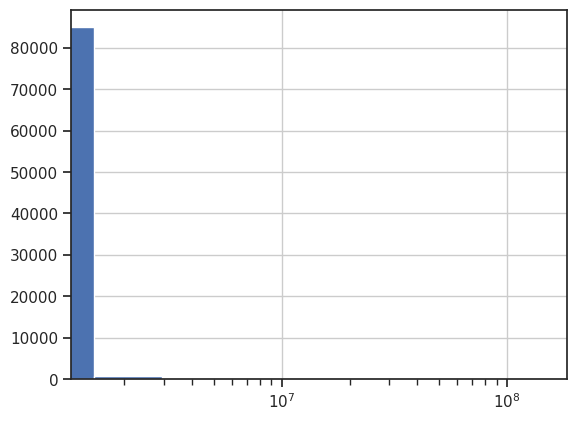

In [4]:
threshold = raw_df[TARGET].quantile(0.995)
print("Top 1% follower threshold:", threshold)
raw_df[TARGET].describe()
raw_df[TARGET].hist(bins=100)
plt.xscale("log")


## Clean columns and save clean_data.csv

In [5]:
df = raw_df.copy()

threshold = df[TARGET].quantile(0.995)
df = df[df[TARGET] <= threshold].copy()

cat_cols = [c for c in CATEGORICAL_COLS if c in df.columns]
for col in cat_cols:
    df[col] = df[col].fillna('unknown')
    df[col] = df[col].astype("category")

if TARGET not in df.columns:
    raise KeyError(f"Target column '{TARGET}' not found after dropping columns")

df[TARGET] = pd.to_numeric(df[TARGET], errors="coerce")
df[TARGET] += 1
df = df.dropna(subset=[TARGET])

numeric_cols = [c for c in df.columns if c not in cat_cols + [TARGET]]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")


missing_rate = df.isna().mean()
high_missing = missing_rate[missing_rate > MISSING_THRESHOLD].index.tolist()
if high_missing:
    print(f"Dropping columns with >{int(MISSING_THRESHOLD*100)}% missing: {high_missing}")
    df = df.drop(columns=high_missing)
    cat_cols = [c for c in cat_cols if c not in high_missing]
    numeric_cols = [c for c in numeric_cols if c not in high_missing]

# Replace inf/-inf with NaN (models handle NaN directly)
df = df.replace([np.inf, -np.inf], np.nan)

clean_path = Path("clean_data.csv")
df.to_csv(clean_path, index=False)
print(f"Cleaned data shape: {df.shape}, saved to {clean_path}")
display(df.head())


Dropping columns with >30% missing: ['genre_entropy', 'closeness']
Cleaned data shape: (86216, 85), saved to clean_data.csv


,artist_mbid,artist_name,artist_id,releases_total,releases_per_year,avg_days_between_releases,release_velocity_releases_per_year,gap_median_days,gap_std_days,max_dry_spell_days,front_loading_index,tracks_total,collab_track_rate,label_diversity_count,label_churn,label_hhi,primary_label,duration_ms_mean,duration_ms_median,duration_ms_min,duration_ms_max,remix_rate,acoustic_rate,genre_count,primary_genre,artist_country,artist_region_city,years_active,primary_role,clust_local,triangles,open_wedges,gwesp_score,degree,log_degree,eigencent,kcore,betweenness,dist_to_hub_min,same_genre_share,same_label_share,same_role_share,tri_within_genre,tri_within_label,tri_within_role,tri_cross_genre,tri_cross_label,tri_cross_role,component_size,open_dyads,weak_tie_frac,community_participation,n2v_0,n2v_1,n2v_2,n2v_3,n2v_4,n2v_5,n2v_6,n2v_7,n2v_8,n2v_9,n2v_10,n2v_11,n2v_12,n2v_13,n2v_14,n2v_15,n2v_16,n2v_17,n2v_18,n2v_19,n2v_20,n2v_21,n2v_22,n2v_23,n2v_24,n2v_25,n2v_26,n2v_27,n2v_28,n2v_29,n2v_30,n2v_31,followers
0,710da3a1-0476-4592-a2f7-5e89dff41eec,Andrew Rangell,0EwuU4DvzAwMq8uYQ3xSiS,1,0.200027,NaN,NaN,NaN,NaN,NaN,1.000000,6,0.000000,1,0,1.000000,RCA Victor Red Seal,249275.500000,257000.0,80000.0,393653.0,0.000000,0.0,0,unknown,United States,Chicago,88.917180,arranger,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000e+00,0.0,0.000000,NaN,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.000000,-0.912142,-0.997900,0.625691,0.144440,0.541359,1.165893,1.003662,-0.058712,-0.433902,-0.500354,-0.841836,-0.658366,-0.224611,-1.036270,-0.771906,1.076072,0.420268,1.733516,-0.471501,1.110615,-0.683630,1.034453,0.354823,-0.635845,0.391959,-0.051464,-0.334433,0.697440,-0.472531,0.439059,0.299475,-0.570884,1371.0
1,710e7188-b3a3-44df-b052-4e3c103a4587,Michele Bravi,1CF7hrTuWgErEa6HBFJ8d3,63,12.594828,28.274194,21.868353,0.0,105.789378,792.0,0.047619,63,0.269841,16,27,0.234568,Columbia Records,167655.661290,173800.0,100000.0,174906.0,0.000000,0.0,2,pop,Italy,Città di Castello,62.086242,composer,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000e+00,0.0,0.000000,NaN,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.000000,0.147646,-0.926421,0.158212,0.355235,-0.559422,0.180172,-0.124296,-0.283972,-0.681095,1.105477,-1.213270,0.286540,-0.474709,-0.081226,-1.096777,1.166940,0.177627,0.022402,-0.553746,0.657499,1.378899,0.446590,0.679968,-0.149896,-0.002211,0.565976,-1.309521,0.443813,-0.476988,-0.382700,0.413173,-1.084927,556473.0
2,710ea276-0833-488b-b1d5-f5d0ba83c671,Louise Kulbicki,1BVI12FSibetu4SRObVHLP,4,0.800110,432.666667,0.650024,123.0,503.653541,1143.0,0.250000,7,1.000000,1,0,1.000000,West One Music,207631.285714,214000.0,79061.0,279000.0,0.000000,0.0,0,unknown,London,unknown,11.507187,composer,1.000000,1.0,0.0,0.786939,2.0,1.098612,1.095923e-17,2.0,0.000000,NaN,1.000000,1.000000,1.000000,1.0,1.0,1.0,0.0,0.0,0.0,4.0,1.0,1.0,0.000000,0.450561,-0.278160,-0.291775,-0.672061,0.438243,0.145051,0.704091,-0.512762,-0.345328,-0.002584,0.449920,-0.229795,0.558565,0.875513,-1.719020,0.328308,1.157591,0.919335,0.174482,1.839316,-0.356073,0.494388,1.424265,-1.882720,-1.053181,0.118262,-0.622879,0.412092,0.460036,-0.022489,0.203211,-0.769053,6.0
3,711034f2-ad91-4470-b0e3-e99e559ef61b,Soap Dodgers,6mbdzxwYn2azIvdjQ9uINq,1,0.199918,NaN,NaN,NaN,NaN,NaN,1.000000,1,1.000000,1,0,1.000000,New State Music,247600.000000,247600.0,247600.0,247600.0,0.000000,0.0,0,unknown,United Kingdom,unknown,14.165640,unknown,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000e+00,0.0,0.000000,NaN,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.000000,0.201180,0.194275,0.988465,0.272061,0.773522,0.145270,0.048118,-0.189131,-0.308898,0.578341,-0.292891,-0.249882,0.507071,0.131101,-1.185988,1.201006,0.849097,-0.277700,-0.117643,1.028403,-0.173812,0.973343,2.397470,-1.559702,0.756467,-0.331834,0.146366,-0.627251,0.293666,-1.790889,0.347935,0.989170,295.0
4,71120df0-0c2c-48ec-9037-46f12631f283,John Lee,5yY5Dd7ek0OzZgy6a7j52E,52,14.443346,23.411765,16.30714

## Build feature sets (non-graph, graph-only, combined)

In [6]:
base_features = [f for f in BASE_FEATURES if f in df.columns]
graph_features = [f for f in GRAPH_FEATURES if f in df.columns]
n2v_features = [f for f in NODE2VEC_FEATURES if f in df.columns]

feature_sets = {
    "base": base_features,
    "graph": graph_features,
    "n2v": n2v_features,
    "base+graph": base_features + graph_features,   
    "base+n2v": base_features + n2v_features,
    "graph+n2v": graph_features + n2v_features,
    "base+graph+n2v": base_features + graph_features + n2v_features,
}

for name, cols in feature_sets.items():
    print(f"{name}: {len(cols)} features")


base: 25 features
graph: 24 features
n2v: 32 features
base+graph: 49 features
base+n2v: 57 features
graph+n2v: 56 features
base+graph+n2v: 81 features


## Train/test split indices (shared across feature sets)

In [7]:
log_followers = np.log1p(df["followers"])

# 2. Bin into quantiles (e.g., 5 or 10 bins)
# qcut handles heavy tails well
df["follower_bin"] = pd.qcut(
    log_followers,
    q=10,          # deciles; 5 is also common
    duplicates="drop"
)

# 3. Stratified split
train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df["follower_bin"]
)

print(f"Train rows: {len(train_idx)}, Test rows: {len(test_idx)}")


Train rows: 68972, Test rows: 17244


In [8]:
import numpy as np
import pandas as pd

from catboost import CatBoostRegressor
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import mean_squared_error, r2_score, make_scorer
from sklearn.experimental import enable_halving_search_cv  # noqa: F401
from sklearn.model_selection import HalvingRandomSearchCV

from scipy.stats import randint, loguniform, uniform

In [9]:

# # ---------------- METRICS (LOG SPACE) ----------------

# def evaluate_log(model_name: str, model, X_eval: pd.DataFrame, y_true_log: np.ndarray):
#     preds_log = model.predict(X_eval)
#     return {
#         "model": model_name,
#         "rmse_log": float(np.sqrt(mean_squared_error(y_true_log, preds_log))),
#         "r2_log": float(r2_score(y_true_log, preds_log)),
#     }

# neg_rmse_log_scorer = make_scorer(
#     lambda yt, yp: np.sqrt(mean_squared_error(yt, yp)),
#     greater_is_better=False
# )
# r2_log_scorer = make_scorer(r2_score, greater_is_better=True)

# FS_KEY = "base+graph+n2v"
# cols = feature_sets.get(FS_KEY, [])
# if not cols:
#     raise ValueError(f'Feature set "{FS_KEY}" not found or empty in feature_sets.')

# X = df.loc[:, cols]
# y = df[TARGET].astype(float)

# X_train = X.loc[train_idx]
# X_test  = X.loc[test_idx]
# y_train = y.loc[train_idx]
# y_test  = y.loc[test_idx]

# # log targets
# y_train_log = np.log1p(y_train.to_numpy())
# y_test_log  = np.log1p(y_test.to_numpy())

# # categorical handling for CatBoost: indices relative to X columns
# cat_cols_fs = [c for c in cat_cols if c in cols]
# cat_idx = [X.columns.get_loc(c) for c in cat_cols_fs]

# # Base estimator used for search
# base_cat = CatBoostRegressor(
#     loss_function="RMSE",
#     eval_metric="RMSE",
#     random_seed=RANDOM_STATE,
#     verbose=False,
#     allow_writing_files=False,
#     cat_features=cat_idx,
#     iterations=3000,      # resource for halving; keep a reasonable ceiling
#     od_type="Iter",
#     thread_count=-1
# )

# # Search space (smart distributions)
# param_distributions = {
#     "depth": randint(4, 11),                 # 4..10
#     "learning_rate": loguniform(1e-3, 2e-1), # 0.001..0.2
#     "l2_leaf_reg": loguniform(1e-1, 1e2),    # 0.1..100
#     "subsample": uniform(0.6, 0.4),          # 0.6..1.0
#     "rsm": uniform(0.6, 0.4),                # 0.6..1.0 (feature subsampling)
#     "min_data_in_leaf": randint(1, 101),     # 1..100
# }

# cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# # Successive halving: evaluates many configs cheaply, promotes winners
# search = HalvingRandomSearchCV(
#     estimator=base_cat,
#     param_distributions=param_distributions,
#     scoring=r2_log_scorer,  # negate RMSE so "higher is better"
#     cv=cv,
#     factor=3,
#     resource="iterations",
#     max_resources=3000,
#     min_resources=200,
#     random_state=RANDOM_STATE,
#     n_jobs=1,        # avoid nested parallelism (CatBoost uses thread_count)
#     verbose=1,
#     refit=True       # refit best params on full X_train/y_train_log (no early stopping)
# )

# print("finished initialization")

# # NOTE: No use_best_model here. No eval_set here.
# # You *may* keep early_stopping_rounds, but without eval_set CatBoost can't do best-model selection.
# # Keeping it doesn't help much; safest is to omit it.
# search.fit(X_train, y_train_log)

# print("finished search fitting")

# best_params = search.best_params_
# best_from_search = search.best_estimator_  # refit-on-train model (no early stopping)

## Load best params and train XGBoost/CatBoost for each feature set

In [10]:
# # This makes training faster + picks best_iteration properly.
# final_cat = CatBoostRegressor(
#     **best_params,
#     loss_function="RMSE",
#     eval_metric="RMSE",
#     random_seed=RANDOM_STATE,
#     verbose=False,
#     allow_writing_files=False,
#     cat_features=cat_idx,
#     od_type="Iter",
#     thread_count=-1,
#     use_best_model=True
# )

# final_cat.fit(
#     X_train,
#     y_train_log,
#     eval_set=(X_test, y_test_log),
#     early_stopping_rounds=200
# )

# best_cat = final_cat

# print("finished final refit")

# cv_estimator = CatBoostRegressor(
#     **best_params,
#     loss_function="RMSE",
#     eval_metric="RMSE",
#     random_seed=RANDOM_STATE,
#     verbose=False,
#     allow_writing_files=False,
#     cat_features=cat_idx,
#     od_type="Iter",
#     thread_count=-1
# )

# scorers = {"rmse_log": neg_rmse_log_scorer, "r2_log": r2_log_scorer}
# cv_cat = cross_validate(
#     cv_estimator,
#     X_train,
#     y_train_log,
#     cv=cv,
#     scoring=scorers,
#     n_jobs=1,
#     error_score="raise",
# )

# print("finished cross validation")

# # ---- Test-set metrics (LOG ONLY) ----
# metrics = evaluate_log("catboost", best_cat, X_test, y_test_log)
# metrics.update(
#     {
#         "feature_set": FS_KEY,
#         "cv_rmse_log_mean": float(-np.mean(cv_cat["test_rmse_log"])),
#         "cv_rmse_log_std":  float(np.std(cv_cat["test_rmse_log"])),
#         "cv_r2_log_mean":   float(np.mean(cv_cat["test_r2_log"])),
#         "cv_r2_log_std":    float(np.std(cv_cat["test_r2_log"])),
#         "best_params": best_params,
#         "best_iteration": int(getattr(best_cat, "best_iteration_", -1)),
#     }
# )

# results_df = pd.DataFrame([metrics])
# display(results_df)

# best_model = best_cat
# best_features = X_test
# feature_names = list(X_train.columns)

In [11]:
best_df = pd.read_csv("best_results.csv")


def load_best_params(model_name: str) -> dict:
    row = best_df.loc[best_df["model"] == model_name]
    if row.empty:
        raise ValueError(f"No params for {model_name} in best_results.csv")
    raw = ast.literal_eval(row.iloc[0]["best_params"])
    return {k.split("__")[-1]: v for k, v in raw.items()}


xgb_params = load_best_params("xgboost")
cat_params = load_best_params("catboost")

In [12]:
# final_cat = CatBoostRegressor(
#     **cat_params,
#     loss_function="RMSE",
#     eval_metric="RMSE",
#     random_seed=RANDOM_STATE,
#     verbose=False,
#     allow_writing_files=False,
#     cat_features=cat_idx,
#     od_type="Iter",
#     thread_count=-1,
#     use_best_model=True
# )

# final_cat.fit(
#     X_train,
#     y_train_log,
#     eval_set=(X_test, y_test_log),
#     early_stopping_rounds=200
# )

# best_cat = final_cat

# print("finished final refit")

# metrics = evaluate_log("catboost", best_cat, X_test, y_test_log)

# results_df = pd.DataFrame([metrics])
# display(results_df)

In [13]:

# # ---- Test-set metrics (LOG ONLY) ----
# metrics = evaluate_log("catboost", best_cat, X_test, y_test_log)
# metrics.update(
#     {
#         "feature_set": FS_KEY,
#         "cv_rmse_log_mean": float(-np.mean(cv_cat["test_rmse_log"])),
#         "cv_rmse_log_std":  float(np.std(cv_cat["test_rmse_log"])),
#         "cv_r2_log_mean":   float(np.mean(cv_cat["test_r2_log"])),
#         "cv_r2_log_std":    float(np.std(cv_cat["test_r2_log"])),
#         "best_params": best_params,
#     }
# )

# results_df = pd.DataFrame([metrics])
# display(results_df)

# best_model = best_cat
# best_features = X_test
# feature_names = list(X_train.columns)

In [ ]:
def encode_for_xgb(frame: pd.DataFrame, cat_subset):
    encoded = frame.copy()
    for col in cat_subset:
        cat = pd.Categorical(encoded[col])
        encoded[col] = pd.Series(cat.codes, index=encoded.index).replace(-1, np.nan)
    return encoded


# ---------- LOG-ONLY METRICS ----------

def evaluate_log(model_name: str, model, X_eval: pd.DataFrame, y_true_log):
    preds_log = model.predict(X_eval)
    return {
        "model": model_name,
        "rmse_log": np.sqrt(mean_squared_error(y_true_log, preds_log)),
        "r2_log": r2_score(y_true_log, preds_log),
    }


def rmse_log_cv(estimator, X, y_true_log):
    preds_log = estimator.predict(X)
    return -np.sqrt(mean_squared_error(y_true_log, preds_log))


def r2_log_cv(estimator, X, y_true_log):
    preds_log = estimator.predict(X)
    return r2_score(y_true_log, preds_log)


# ---------------- RUN ----------------

results = []
trained = {}

for fs_name, cols in feature_sets.items():
    print(fs_name)
    if not cols:
        print(f"Skipping {fs_name} (no features).")
        continue

    X = df.loc[:, cols]
    y = df[TARGET].astype(float)

    X_train = X.loc[train_idx]
    X_test = X.loc[test_idx]
    y_train = y.loc[train_idx]
    y_test = y.loc[test_idx]

    # log targets (ONLY thing we score/store)
    y_train_log = np.log1p(y_train)
    y_test_log = np.log1p(y_test)

    # categorical handling
    cat_cols_fs = [c for c in cat_cols if c in cols]
    cat_idx = [X.columns.get_loc(c) for c in cat_cols_fs]

    X_train_xgb = encode_for_xgb(X_train, cat_cols_fs)
    X_test_xgb = encode_for_xgb(X_test, cat_cols_fs)

    # models
    xgb_model = XGBRegressor(
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        tree_method="hist",
        enable_categorical=True,
        n_jobs=-1,
        **xgb_params,
    )

    cat_model = CatBoostRegressor(
        loss_function="RMSE",
        random_seed=RANDOM_STATE,
        verbose=0,
        allow_writing_files=False,
        cat_features=cat_idx,
        **cat_params,
    )

    # CV scorers (LOG ONLY)
    scorers = {"rmse_log": rmse_log_cv, "r2_log": r2_log_cv}

    cv_xgb = cross_validate(
        xgb_model,
        X_train_xgb,
        y_train_log,
        cv=5,
        scoring=scorers,
        n_jobs=1,
        error_score="raise",
    )
    cv_cat = cross_validate(
        cat_model,
        X_train,
        y_train_log,
        cv=5,
        scoring=scorers,
        n_jobs=1,
        error_score="raise",
    )

    # fit on full train split (log target)
    xgb_model.fit(X_train_xgb, y_train_log)
    cat_model.fit(X_train, y_train_log)

    # test-set metrics (LOG ONLY)
    metrics = [
        evaluate_log("xgboost", xgb_model, X_test_xgb, y_test_log),
        evaluate_log("catboost", cat_model, X_test, y_test_log),
    ]

    # attach CV summary (LOG ONLY)
    metrics[0].update(
        {
            "cv_rmse_log_mean": -np.mean(cv_xgb["test_rmse_log"]),
            "cv_rmse_log_std": np.std(cv_xgb["test_rmse_log"]),
            "cv_r2_log_mean": np.mean(cv_xgb["test_r2_log"]),
            "cv_r2_log_std": np.std(cv_xgb["test_r2_log"]),
        }
    )
    metrics[1].update(
        {
            "cv_rmse_log_mean": -np.mean(cv_cat["test_rmse_log"]),
            "cv_rmse_log_std": np.std(cv_cat["test_rmse_log"]),
            "cv_r2_log_mean": np.mean(cv_cat["test_r2_log"]),
            "cv_r2_log_std": np.std(cv_cat["test_r2_log"]),
        }
    )

    for m in metrics:
        m["feature_set"] = fs_name
    results.extend(metrics)

    trained[(fs_name, "xgboost")] = {
        "model": xgb_model,
        "X_test": X_test_xgb,
        "feature_names": list(X_train_xgb.columns),
    }
    trained[(fs_name, "catboost")] = {
        "model": cat_model,
        "X_test": X_test,
        "feature_names": list(X_train.columns),
    }

results_df = (
    pd.DataFrame(results)
    .sort_values(["rmse_log", "cv_rmse_log_mean"])
    .reset_index(drop=True)
)
display(results_df)

best_row = results_df.iloc[0]
print(f"Best overall (log metrics): {best_row['model']} on {best_row['feature_set']}")
best_key = (best_row["feature_set"], best_row["model"])
best_bundle = trained[best_key]
best_model = best_bundle["model"]
best_features = best_bundle["X_test"]
feature_names = best_bundle["feature_names"]

base


In [ ]:
results_df.to_csv('results.csv')

In [ ]:
results_df[results_df['model'] == 'catboost'].sort_values('r2_log').drop(columns=['model'])

,rmse_log,r2_log,cv_rmse_log_mean,cv_rmse_log_std,cv_r2_log_mean,cv_r2_log_std,feature_set
7,2.692071,0.254535,2.704363,0.011140,0.254754,0.005769,graph
5,2.652413,0.276337,2.660677,0.011045,0.278629,0.006526,n2v
4,2.549833,0.331229,2.561712,0.013160,0.331289,0.007192,graph+n2v
3,2.535571,0.338689,2.562828,0.011998,0.330728,0.004391,base
2,2.429338,0.392942,2.451212,0.011893,0.387746,0.005263,base+graph
1,2.407849,0.403634,2.422867,0.012282,0.401789,0.008416,base+n2v
0,2.375882,0.419364,2.391497,0.013593,0.417190,0.007684,base+graph+n2v


In [ ]:

# best_df = pd.read_csv("best_results.csv")


# def load_best_params(model_name: str) -> dict:
#     row = best_df.loc[best_df["model"] == model_name]
#     if row.empty:
#         raise ValueError(f"No params for {model_name} in best_results.csv")
#     raw = ast.literal_eval(row.iloc[0]["best_params"])
#     return {k.split("__")[-1]: v for k, v in raw.items()}


# # Only load CatBoost params now
# cat_params = load_best_params("catboost")


# def evaluate(model_name: str, model, X_eval: pd.DataFrame, y_true, y_true_log):
#     preds_log = model.predict(X_eval)
#     preds = np.expm1(preds_log)
#     return {
#         "model": model_name,
#         "rmse": np.sqrt(mean_squared_error(y_true, preds)),
#         "mae": mean_absolute_error(y_true, preds),
#         "r2": r2_score(y_true, preds),
#         "rmse_log": np.sqrt(mean_squared_error(y_true_log, preds_log)),
#         "r2_log": r2_score(y_true_log, preds_log),
#     }


# results = []
# trained = {}

# for fs_name, cols in feature_sets.items():
#     print(fs_name)
#     if not cols:
#         print(f"Skipping {fs_name} (no features).")
#         continue

#     X = df.loc[:, cols]
#     y = df[TARGET].astype(float)

#     X_train = X.loc[train_idx]
#     X_test = X.loc[test_idx]
#     y_train = y.loc[train_idx]
#     y_test = y.loc[test_idx]

#     cat_cols_fs = [c for c in cat_cols if c in cols]
#     cat_idx = [X.columns.get_loc(c) for c in cat_cols_fs]

#     y_train_log = np.log1p(y_train)
#     y_test_log = np.log1p(y_test)

#     cat_model = CatBoostRegressor(
#         loss_function="RMSE",
#         random_seed=RANDOM_STATE,
#         verbose=0,
#         allow_writing_files=False,
#         cat_features=cat_idx,
#         **cat_params,
#     )

#     # Simple train / test (no cross-validation)
#     cat_model.fit(X_train, y_train_log)

#     metrics = evaluate("catboost", cat_model, X_test, y_test, y_test_log)
#     metrics["feature_set"] = fs_name
#     results.append(metrics)

#     trained[(fs_name, "catboost")] = {
#         "model": cat_model,
#         "X_test": X_test,
#         "feature_names": list(X_train.columns),
#     }

# results_df = (
#     pd.DataFrame(results)
#     .sort_values(["rmse", "rmse_log"])
#     .reset_index(drop=True)
# )
# display(results_df)

# best_row = results_df.iloc[0]
# print(f"Best overall: {best_row['model']} on {best_row['feature_set']}")
# best_key = (best_row["feature_set"], best_row["model"])
# best_bundle = trained[best_key]
# best_model = best_bundle["model"]
# best_features = best_bundle["X_test"]
# feature_names = best_bundle["feature_names"]

In [ ]:
# def encode_for_xgb(frame: pd.DataFrame, cat_subset):
#     encoded = frame.copy()
#     for col in cat_subset:
#         cat = pd.Categorical(encoded[col])
#         encoded[col] = pd.Series(cat.codes, index=encoded.index).replace(-1, np.nan)
#     return encoded


# def evaluate(model_name: str, model, X_eval: pd.DataFrame, y_true, y_true_log):
#     preds_log = model.predict(X_eval)
#     preds = np.expm1(preds_log)
#     return {
#         "model": model_name,
#         "rmse": np.sqrt(mean_squared_error(y_true, preds)),
#         "mae": mean_absolute_error(y_true, preds),
#         "r2": r2_score(y_true, preds),
#         "rmse_log": np.sqrt(mean_squared_error(y_true_log, preds_log)),
#         "r2_log": r2_score(y_true_log, preds_log),
#     }


# results = []
# trained = {}

# for fs_name, cols in feature_sets.items():
#     print(fs_name)

#     X = df.loc[:, cols]
#     y = df[TARGET].astype(float)

#     X_train = X.loc[train_idx]
#     X_test = X.loc[test_idx]
#     y_train = y.loc[train_idx]
#     y_test = y.loc[test_idx]

#     cat_cols_fs = [c for c in cat_cols if c in cols]
#     cat_idx = [X.columns.get_loc(c) for c in cat_cols_fs]

#     X_train_xgb = encode_for_xgb(X_train, cat_cols_fs)
#     X_test_xgb = encode_for_xgb(X_test, cat_cols_fs)

#     y_train_log = np.log1p(y_train)
#     y_test_log = np.log1p(y_test)

#     # No best_params here – use whatever fixed/default params you want
#     # xgb_model = XGBRegressor(
#     #     objective="reg:squarederror",
#     #     random_state=RANDOM_STATE,
#     #     tree_method="hist",
#     #     enable_categorical=True,
#     #     n_jobs=-1,
#     # )

#     cat_model = CatBoostRegressor(
#         loss_function="RMSE",
#         random_seed=RANDOM_STATE,
#         verbose=0,
#         allow_writing_files=False,
#         cat_features=cat_idx,
#     )

#     # Train on train set only
#     # xgb_model.fit(X_train_xgb, y_train_log)
#     cat_model.fit(X_train, y_train_log)

#     # Evaluate on test set only
#     metrics = [
#         # evaluate("xgboost", xgb_model, X_test_xgb, y_test, y_test_log),
#         evaluate("catboost", cat_model, X_test, y_test, y_test_log),
#     ]

#     for m in metrics:
#         m["feature_set"] = fs_name
#     results.extend(metrics)

#     # trained[(fs_name, "xgboost")] = {
#     #     "model": xgb_model,
#     #     "X_test": X_test_xgb,
#     #     "feature_names": list(X_train_xgb.columns),
#     # }
#     trained[(fs_name, "catboost")] = {
#         "model": cat_model,
#         "X_test": X_test,
#         "feature_names": list(X_train.columns),
#     }

# results_df = pd.DataFrame(results).sort_values(["rmse", "rmse_log"]).reset_index(drop=True)
# display(results_df)

# best_row = results_df.iloc[0]
# print(f"Best overall: {best_row['model']} on {best_row['feature_set']}")
# best_key = (best_row["feature_set"], best_row["model"])
# best_bundle = trained[best_key]
# best_model = best_bundle["model"]
# best_features = best_bundle["X_test"]
# feature_names = best_bundle["feature_names"]


## Feature importance for the best model

,importance
artist_country,7.853131
artist_region_city,6.444394
primary_role,5.047846
primary_label,4.545301
years_active,4.171476
...,...
acoustic_rate,0.092550
tri_within_label,0.089177
genre_count,0.068116
component_size,0.067914


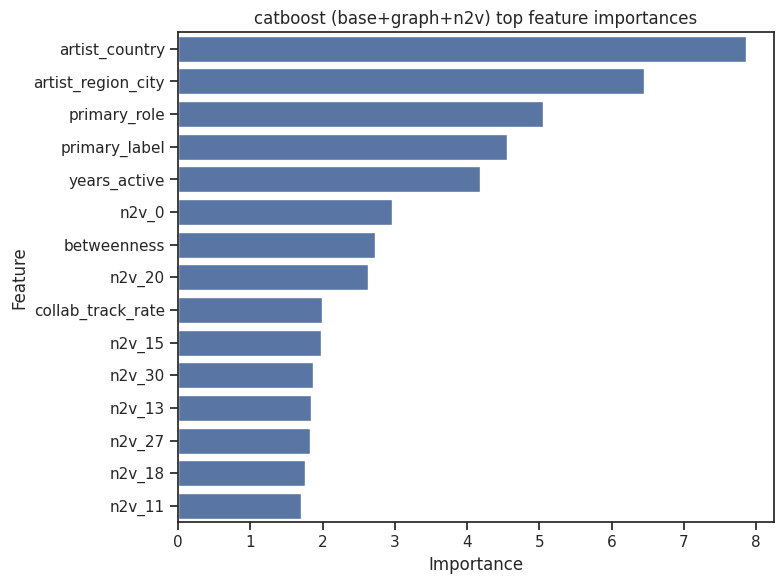

In [ ]:
if best_row["model"] == "catboost":
    importances = pd.Series(
        best_model.get_feature_importance(type="FeatureImportance"),
        index=feature_names,
    )
else:
    importances = pd.Series(best_model.feature_importances_, index=feature_names)

importances = importances.sort_values(ascending=False)
display(importances.to_frame("importance"))

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values[:15], y=importances.index[:15])
plt.title(f"{best_row['model']} ({best_row['feature_set']}) top feature importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## SHAP summary plot for the best model

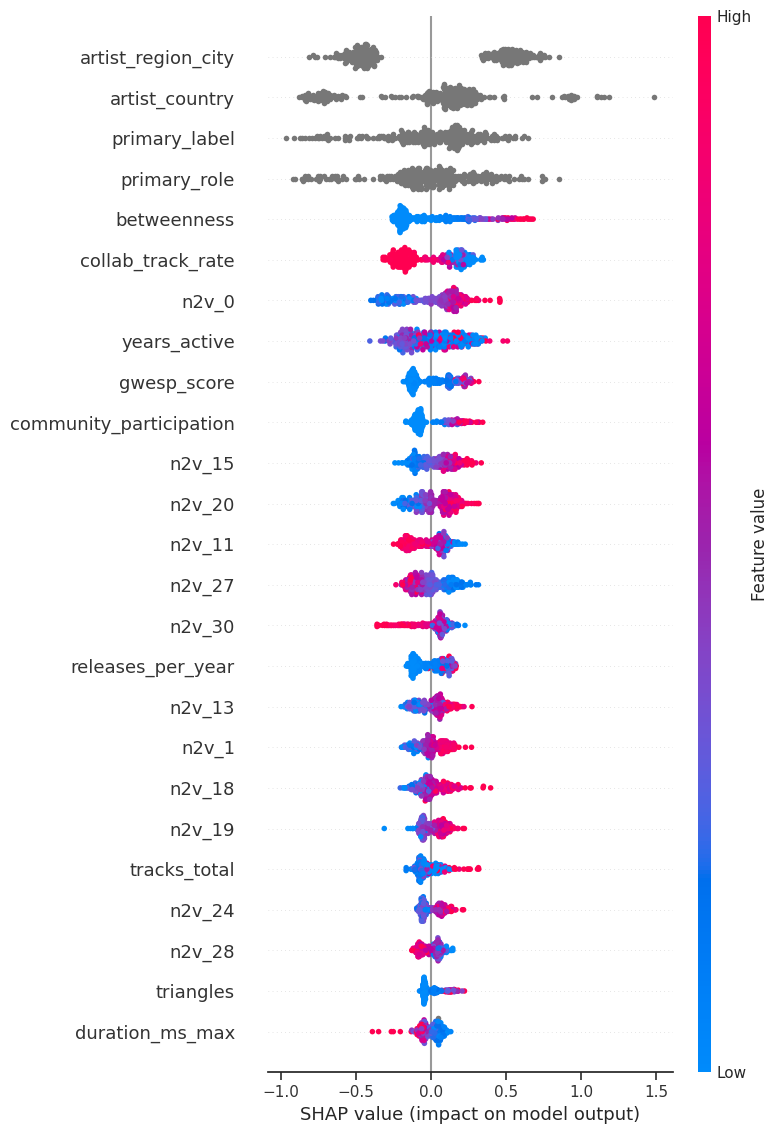

In [ ]:
sample = best_features.sample(
    n=min(300, len(best_features)), random_state=RANDOM_STATE
)
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(sample)

shap.summary_plot(
    shap_values,
    features=sample,
    feature_names=feature_names,
    show=False,
    max_display=25,
)
plt.tight_layout()
plt.show()


## Experience-Segmented Modeling Case Study (>8 train, <8 rank)

Train models using only artists with more than 8 years of experience (`years_active > 8`),
then rank the remaining artists with less than 8 years (`years_active < 8`) by predicted followers.


In [ ]:
if 'years_active' not in df.columns:
    raise KeyError("Column 'years_active' is required for this case study.")

# Keep only rows with non-null experience and split by threshold
df_exp = df.dropna(subset=['years_active']).copy()
train_mask = df_exp['years_active'] > 5
case_mask = df_exp['years_active'] < 5

train_df_exp = df_exp.loc[train_mask].copy()
case_df_exp = df_exp.loc[case_mask].copy()

print(f"Training pool (years_active > 8): {len(train_df_exp):,}")
print(f"Case-study pool (years_active < 8): {len(case_df_exp):,}")

if len(train_df_exp) < 50:
    raise ValueError('Too few rows in years_active > 8 subset for stable training.')
if len(case_df_exp) == 0:
    raise ValueError('No rows found with years_active < 8.')

# Use one full feature set only: base + graph + n2v
fs_name = 'base+graph+n2v'
cols = feature_sets.get(fs_name, [])
if not cols:
    raise ValueError(f"Feature set '{fs_name}' is empty or missing.")

id_cols = [c for c in ['artist_name', 'artist_id', 'artist_mbid'] if c in case_df_exp.columns]

X_train = train_df_exp.loc[:, cols]
y_train_log = np.log1p(train_df_exp[TARGET].astype(float))
X_case = case_df_exp.loc[:, cols]

cat_cols_fs = [c for c in cat_cols if c in cols]
cat_idx = [X_train.columns.get_loc(c) for c in cat_cols_fs]

cat_model = CatBoostRegressor(
    loss_function='RMSE',
    random_seed=RANDOM_STATE,
    verbose=0,
    allow_writing_files=False,
    cat_features=cat_idx,
    **cat_params,
)

cat_model.fit(X_train, y_train_log)

pred_log_cat = cat_model.predict(X_case)

pred_followers_cat = np.expm1(pred_log_cat)

ranking_base = pd.DataFrame(index=case_df_exp.index)
for c in id_cols:
    ranking_base[c] = case_df_exp[c].values
if not id_cols:
    ranking_base['artist_row_id'] = case_df_exp.index
ranking_base['years_active'] = case_df_exp['years_active'].values
# TARGET was shifted by +1 earlier for modeling; convert back to actual followers.
ranking_base['actual_followers'] = np.maximum(case_df_exp[TARGET].astype(float).values - 1.0, 0.0)

case_rankings = {
    (fs_name, 'catboost'): (
        ranking_base.assign(pred_followers=pred_followers_cat)
        .sort_values('pred_followers', ascending=False)
        .reset_index(drop=True)
    ),
}

case_summary_df = pd.DataFrame([
    {
        'feature_set': fs_name,
        'model': 'catboost',
        'case_pool_size': len(case_df_exp),
        'pred_followers_mean': float(np.mean(pred_followers_cat)),
        'pred_followers_median': float(np.median(pred_followers_cat)),
        'pred_followers_top10_mean': float(np.mean(np.sort(pred_followers_cat)[-10:])),
    },
]).sort_values(['pred_followers_top10_mean', 'pred_followers_mean'], ascending=False).reset_index(drop=True)

display(case_summary_df)

best_case_row = case_summary_df.iloc[0]
best_case_key = (best_case_row['feature_set'], best_case_row['model'])
print(f"Best case-study ranking model: {best_case_key[1]} on {best_case_key[0]}")


Training pool (years_active > 8): 72,928
Case-study pool (years_active < 8): 13,288


,feature_set,model,case_pool_size,pred_followers_mean,pred_followers_median,pred_followers_top10_mean
0,base+graph+n2v,catboost,13288,5702.523887,1146.621228,387284.749606


Best case-study ranking model: catboost on base+graph+n2v


In [ ]:
rankings = case_rankings[list(case_rankings.keys())[0]]
rankings.actual_followers = rankings.actual_followers.astype(int)
rankings.pred_followers = rankings.pred_followers.astype(int)

rankings.head(10)[['artist_name', 'pred_followers', 'actual_followers']]

,artist_name,pred_followers,actual_followers
0,Asal Kolaar,474759,1129202
1,Ken Carson,463295,3216955
2,tripleS,456187,684622
3,Melissa Robles,451741,42769
4,Mr. Monkey,386993,5693
5,Lavita Lobo,364115,3384
6,Al Tiro de Armando Ramos,343991,9564
7,V.M. Mahalingam,319925,33207
8,EVNNE,315240,195740
9,Rahul Sipligunj,296597,1576019
